In [11]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

import statsmodels.formula.api as smf
from scipy.stats import chi2

clean = pd.read_csv("processed/diabetes_preprocessed_stage1.csv")

print(clean.shape)
clean.head()

Matplotlib is building the font cache; this may take a moment.


(69987, 56)


,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,...,diabetesMed,readmitted,readmitted_30,a1c_group,diag1_group,age_group,specialty_group,race_group,admission_source_group,discharge_group
0,24437208,135,Caucasian,Female,[50-60),2,1,1,8,Cardiology,...,Yes,<30,1,Not measured,Circulatory,30-60,Cardiology,Caucasian,Referral,Home
1,29758806,378,Caucasian,Female,[50-60),3,1,1,2,Surgery-Neuro,...,No,NO,0,Not measured,Musculoskeletal,30-60,Surgery,Caucasian,Referral,Home
2,189899286,729,Caucasian,Female,[80-90),1,3,7,4,InternalMedicine,...,Yes,NO,0,Normal/near-normal measured,Injury,60+,Internal Medicine,Caucasian,Emergency,Other
3,64331490,774,Caucasian,Female,[80-90),1,1,7,3,InternalMedicine,...,Yes,NO,0,"High, medication changed",Other,60+,Internal Medicine,Caucasian,Emergency,Home
4,14824206,927,AfricanAmerican,Female,[30-40),1,1,7,5,InternalMedicine,...,Yes,NO,0,Not measured,Genitourinary,30-60,Internal Medicine,African American,Emergency,Home


In [2]:
def likelihood_ratio_test(smaller_model, larger_model):
    """
    Compare two nested logistic regression models.

    smaller_model: simpler model
    larger_model: more complex model

    Returns likelihood-ratio statistic, degrees of freedom difference, and p-value.
    """
    lr_stat = 2 * (larger_model.llf - smaller_model.llf)
    df_diff = larger_model.df_model - smaller_model.df_model
    p_value = chi2.sf(lr_stat, df_diff)

    return {
        "lr_stat": lr_stat,
        "df_diff": df_diff,
        "p_value": p_value
    }


def odds_ratio_table(model):
    """
    Convert statsmodels logistic regression output into a nicer table.
    """
    params = model.params
    conf = model.conf_int()
    pvalues = model.pvalues

    result = pd.DataFrame({
        "coef": params,
        "odds_ratio": np.exp(params),
        "ci_lower": np.exp(conf[0]),
        "ci_upper": np.exp(conf[1]),
        "p_value": pvalues
    })

    return result

In [3]:
formula_core = """
readmitted_30 ~ 
C(discharge_group, Treatment(reference="Home"))
+ C(race_group, Treatment(reference="African American"))
+ C(admission_source_group, Treatment(reference="Emergency"))
+ C(specialty_group, Treatment(reference="Cardiology"))
+ time_in_hospital
+ C(age_group, Treatment(reference="30-60"))
+ C(diag1_group, Treatment(reference="Diabetes"))
"""

core_model = smf.logit(formula_core, data=clean).fit(maxiter=200)

print(core_model.summary())

Optimization terminated successfully.
         Current function value: 0.296355
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:          readmitted_30   No. Observations:                69987
Model:                          Logit   Df Residuals:                    69964
Method:                           MLE   Df Model:                           22
Date:                Sat, 04 Jul 2026   Pseudo R-squ.:                 0.01895
Time:                        17:56:27   Log-Likelihood:                -20741.
converged:                       True   LL-Null:                       -21142.
Covariance Type:            nonrobust   LLR p-value:                2.928e-155
                                                                                       coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------

In [4]:
formula_a1c = formula_core + """
+ C(a1c_group, Treatment(reference="Not measured"))
"""

a1c_model = smf.logit(formula_a1c, data=clean).fit(maxiter=200)

print(a1c_model.summary())

Optimization terminated successfully.
         Current function value: 0.296294
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:          readmitted_30   No. Observations:                69987
Model:                          Logit   Df Residuals:                    69961
Method:                           MLE   Df Model:                           25
Date:                Sat, 04 Jul 2026   Pseudo R-squ.:                 0.01916
Time:                        17:56:34   Log-Likelihood:                -20737.
converged:                       True   LL-Null:                       -21142.
Covariance Type:            nonrobust   LLR p-value:                9.383e-155
                                                                                        coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------

In [5]:
formula_a1c_diag_interaction = formula_a1c + """
+ C(a1c_group, Treatment(reference="Not measured")):C(diag1_group, Treatment(reference="Diabetes"))
"""

interaction_model = smf.logit(
    formula_a1c_diag_interaction,
    data=clean
).fit(maxiter=300)

print(interaction_model.summary())

Optimization terminated successfully.
         Current function value: 0.295948
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:          readmitted_30   No. Observations:                69987
Model:                          Logit   Df Residuals:                    69937
Method:                           MLE   Df Model:                           49
Date:                Sat, 04 Jul 2026   Pseudo R-squ.:                 0.02030
Time:                        17:56:56   Log-Likelihood:                -20713.
converged:                       True   LL-Null:                       -21142.
Covariance Type:            nonrobust   LLR p-value:                2.525e-148
                                                                                                                                                           coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------

In [6]:
likelihood_ratio_test(a1c_model, interaction_model)

{'lr_stat': np.float64(48.35011414477776),
 'df_diff': 24.0,
 'p_value': np.float64(0.0022837980076492338)}

In [7]:
Path("outputs").mkdir(exist_ok=True)

core_or = odds_ratio_table(core_model)
a1c_or = odds_ratio_table(a1c_model)
interaction_or = odds_ratio_table(interaction_model)

core_or.to_csv("outputs/logistic_core_model_odds_ratios.csv")
a1c_or.to_csv("outputs/logistic_a1c_model_odds_ratios.csv")
interaction_or.to_csv("outputs/logistic_interaction_model_odds_ratios.csv")

print("Saved logistic regression output tables.")

Saved logistic regression output tables.


In [8]:
a1c_order = [
    "Not measured",
    "Normal/near-normal measured",
    "High, medication changed",
    "High, medication not changed"
]

diag_order = [
    "Diabetes",
    "Respiratory",
    "Circulatory"
]

prediction_rows = []

for diag in diag_order:
    for a1c in a1c_order:
        prediction_rows.append({
            "a1c_group": a1c,
            "diag1_group": diag,
            "discharge_group": "Home",
            "race_group": "African American",
            "admission_source_group": "Emergency",
            "specialty_group": "Cardiology",
            "time_in_hospital": clean["time_in_hospital"].mean(),
            "age_group": "30-60"
        })

prediction_grid = pd.DataFrame(prediction_rows)

prediction_grid["predicted_readmission_probability"] = interaction_model.predict(
    prediction_grid
)

prediction_grid

,a1c_group,diag1_group,discharge_group,race_group,admission_source_group,specialty_group,time_in_hospital,age_group,predicted_readmission_probability
0,Not measured,Diabetes,Home,African American,Emergency,Cardiology,4.273336,30-60,0.064754
1,Normal/near-normal measured,Diabetes,Home,African American,Emergency,Cardiology,4.273336,30-60,0.066932
2,"High, medication changed",Diabetes,Home,African American,Emergency,Cardiology,4.273336,30-60,0.044353
3,"High, medication not changed",Diabetes,Home,African American,Emergency,Cardiology,4.273336,30-60,0.035162
4,Not measured,Respiratory,Home,African American,Emergency,Cardiology,4.273336,30-60,0.047893
5,Normal/near-normal measured,Respiratory,Home,African American,Emergency,Cardiology,4.273336,30-60,0.030186
6,"High, medication changed",Respiratory,Home,African American,Emergency,Cardiology,4.273336,30-60,0.045303
7,"High, medication not changed",Respiratory,Home,African American,Emergency,Cardiology,4.273336,30-60,0.040620
8,Not measured,Circulatory,Home,African American,Emergency,Cardiology,4.273336,30-60,0.060213
9,Normal/near-normal measured,Circulatory,Home,African American,Emergency,Cardiology,4.273336,30-60,0.057889


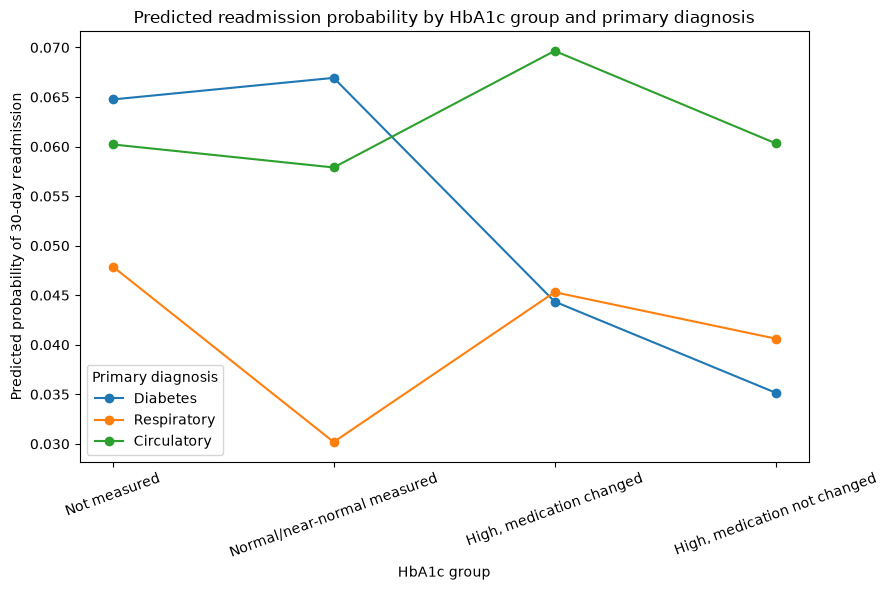

In [12]:
plt.figure(figsize=(9, 6))

for diag in diag_order:
    subset = prediction_grid[prediction_grid["diag1_group"] == diag]

    plt.plot(
        subset["a1c_group"],
        subset["predicted_readmission_probability"],
        marker="o",
        label=diag
    )

plt.xlabel("HbA1c group")
plt.ylabel("Predicted probability of 30-day readmission")
plt.title("Predicted readmission probability by HbA1c group and primary diagnosis")
plt.xticks(rotation=20)
plt.legend(title="Primary diagnosis")
plt.tight_layout()

plt.savefig("outputs/figure1_like_predicted_readmission.png", dpi=300)
plt.show()